# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## What is DBSCAN?
DBSCAN is an **unsupervised machine learning clustering algorithm** that groups together points that are closely packed and marks isolated points as **noise (outliers)**.

---

## Key Idea
- Points in **high-density regions** form a cluster.
- Points in **low-density regions** are treated as noise.

---

## Parameters

### 1. eps (ε)
- Maximum distance between two points to be considered neighbors.
- Larger `eps` → fewer clusters.
- Smaller `eps` → more clusters and more noise.

### 2. min_samples
- Minimum number of neighboring points required to form a dense region.
- Higher value → stricter clustering.
- Lower value → more clusters may form.

---

## Types of Points

### Core Point
A point with at least `min_samples` neighbors within `eps`.

### Border Point
A point within the `eps` distance of a core point but has fewer than `min_samples` neighbors.

### Noise Point (Outlier)
A point that is not connected to any cluster.

---

## Working Steps
1. Choose `eps` and `min_samples`.
2. Find neighbors of each point.
3. Identify core points.
4. Expand clusters from core points.
5. Assign border points to nearby clusters.
6. Mark remaining points as noise.

---

## Advantages
- No need to specify the number of clusters.
- Detects outliers automatically.
- Works well for clusters of arbitrary shapes.
- Robust to noise.

---

## Disadvantages
- Choosing `eps` can be difficult.
- Performs poorly when cluster densities vary significantly.
- Less effective in very high-dimensional data.

---

## Applications
- Customer segmentation
- Anomaly detection
- Image segmentation
- GPS/location data analysis
- Fraud detection

---

## Choosing `eps`
Use a **K-Nearest Neighbor (KNN) Distance Plot**.
The **elbow point** in the graph is a good estimate for `eps`.

---

## Evaluation
For unlabeled data, common evaluation metrics include:
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

---

## When to Use DBSCAN
Use DBSCAN when:
- The number of clusters is unknown.
- The dataset contains outliers.
- Clusters have irregular (non-spherical) shapes.
- You want automatic noise detection.

---

## Comparison with K-Means

| Feature | K-Means | DBSCAN |
|---------|---------|---------|
| Supervision | Unsupervised | Unsupervised |
| Need to specify clusters | Yes (`k`) | No |
| Detects outliers | No | Yes |
| Cluster shape | Mostly spherical | Any shape |
| Sensitive to noise | Yes | No |
| Handles arbitrary shapes | No | Yes |

---

## Summary
- **Algorithm:** DBSCAN
- **Type:** Density-based clustering
- **Input:** Unlabeled data
- **Main Parameters:** `eps`, `min_samples`
- **Output:** Clusters + Noise Points
- **Best For:** Arbitrary-shaped clusters and outlier detection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Generate Unlabelled Dataset

In [2]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=600, noise=0.08, random_state=42)

data = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

data.head()

,Feature1,Feature2
0,0.474333,0.954791
1,0.689439,-0.444271
2,1.821709,0.119633
3,0.761090,0.704928
4,-0.321413,0.851637


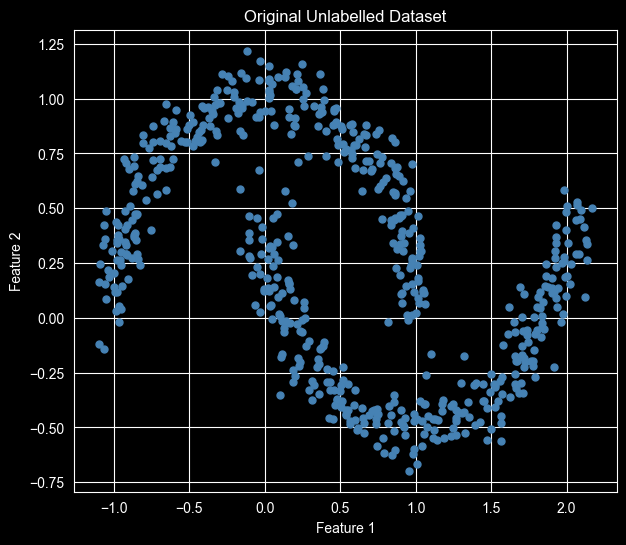

In [6]:
plt.figure(figsize=(7, 6))

plt.scatter(data['Feature1'], data['Feature2'], s=25, color='steelblue')

plt.title("Original Unlabelled Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)

plt.show()

### 2. Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### 3. Find Optimal eps using K-Nearest Neighbor Distance Plot

- Choose min_samples = 5

In [8]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])

### 4. Plot KNN Distance Graph

- The "elbow" indicates a good value for eps.

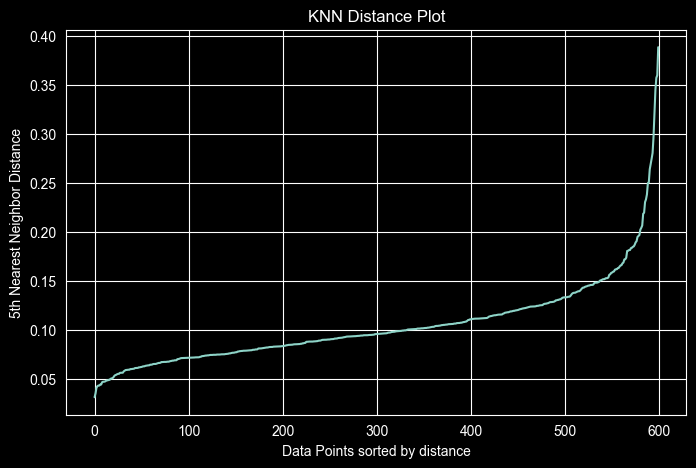

In [9]:
plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title("KNN Distance Plot")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")

plt.grid(True)

plt.show()

### 5. Train DBSCAN Model

In [10]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.22, min_samples=5)

clusters = dbscan.fit_predict(X_scaled)

clusters[:15]

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1])

In [11]:
# Add Cluster Labels

data['Cluster'] = clusters

data.head()

,Feature1,Feature2,Cluster
0,0.474333,0.954791,0
1,0.689439,-0.444271,1
2,1.821709,0.119633,1
3,0.761090,0.704928,0
4,-0.321413,0.851637,0


### 6. Number of Clusters

In [12]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

noise_points = list(clusters).count(-1)

print("Number of clusters :", n_clusters)
print("Noise points :", noise_points)

Number of clusters : 2
Noise points : 8


In [13]:
print(data["Cluster"].value_counts())

Cluster
 0    297
 1    295
-1      8
Name: count, dtype: int64


### 7. Visualize Clusters

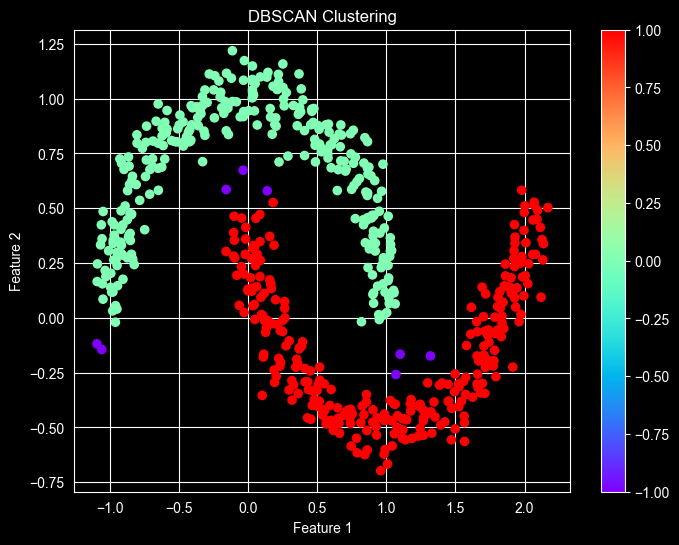

In [14]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap="rainbow",
    s=35
)

plt.title("DBSCAN Clustering")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.colorbar(scatter)

plt.grid(True)

plt.show()

### 8. Highlight Noise Points

- Noise points have label -1.

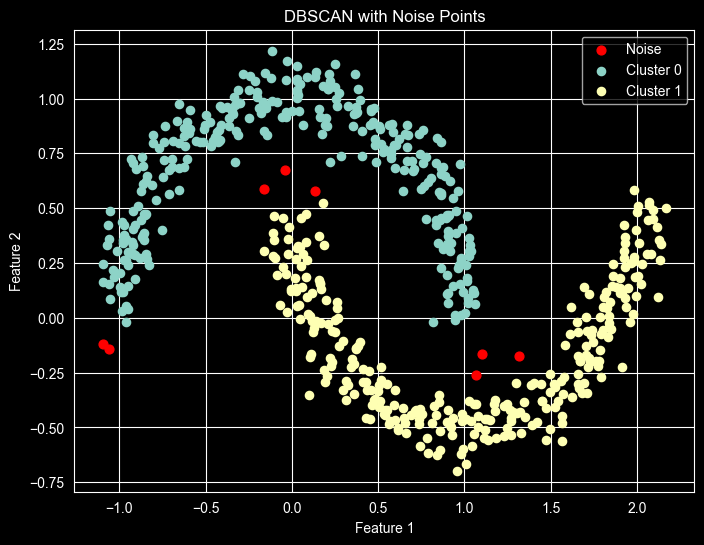

In [17]:
plt.figure(figsize=(8,6))

unique_labels = np.unique(clusters)

for label in unique_labels:

    if label == -1:

        plt.scatter(
            X[clusters==label,0],
            X[clusters==label,1],
            color='red',
            s=40,
            label="Noise"
        )

    else:

        plt.scatter(
            X[clusters==label,0],
            X[clusters==label,1],
            s=35,
            label=f"Cluster {label}"
        )

plt.title("DBSCAN with Noise Points")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.grid(True)

plt.show()

### 9. Silhouette Score

- Ignore noise points while calculating silhouette score.

In [19]:
from sklearn.metrics import silhouette_score

mask = clusters != -1

if len(set(clusters[mask])) > 1:

    score = silhouette_score(
        X_scaled[mask],
        clusters[mask]
    )

    print("Silhouette Score :", round(score,3))

else:

    print("Silhouette Score cannot be calculated.")

Silhouette Score : 0.392


### 10. Cluster Statistics

In [20]:
cluster_summary = data.groupby("Cluster").mean()

cluster_summary

,Feature1,Feature2
Cluster,,
-1,0.158187,0.122137
0,0.005833,0.650949
1,1.011382,-0.134829


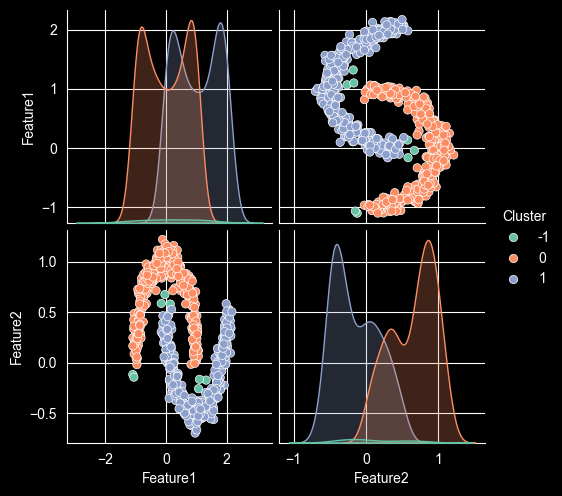

In [21]:
import seaborn as sns

sns.pairplot(
    data,
    hue="Cluster",
    palette="Set2"
)

plt.show()

### 11. Effect of Different eps Values

- This plot clearly demonstrates how the choice of eps influences the number of detected clusters and the amount of noise.

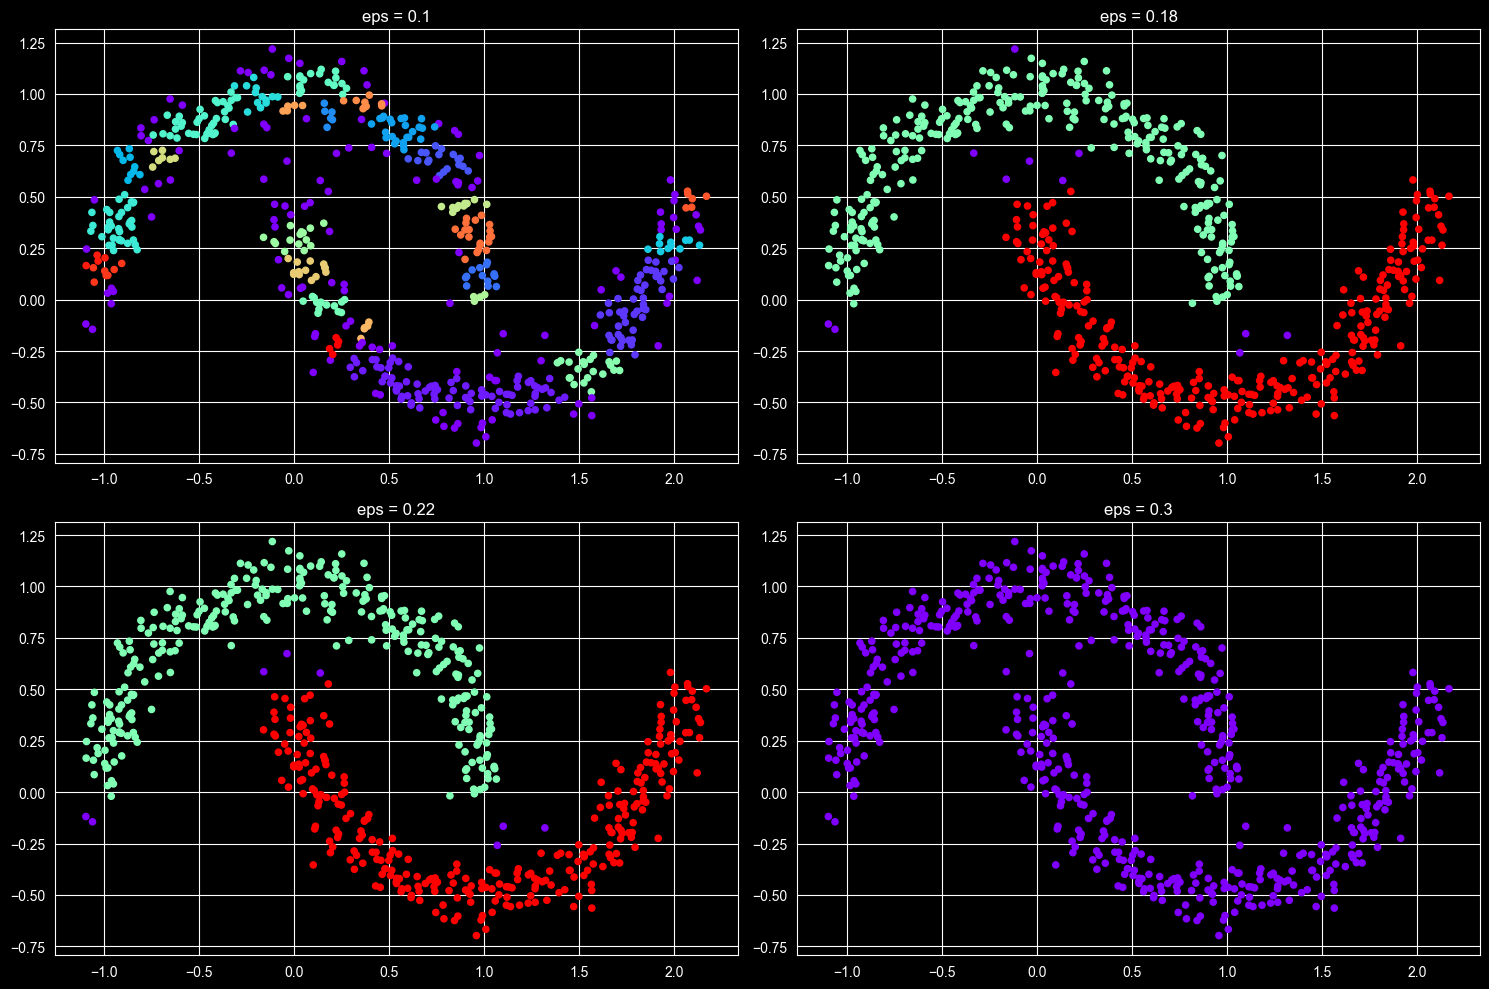

In [22]:
eps_values = [0.10, 0.18, 0.22, 0.30]

plt.figure(figsize=(15,10))

for i, eps in enumerate(eps_values):

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    plt.subplot(2,2,i+1)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="rainbow",
        s=20
    )

    plt.title(f"eps = {eps}")

plt.tight_layout()

plt.show()

### 12. Effect of Different min_samples Values

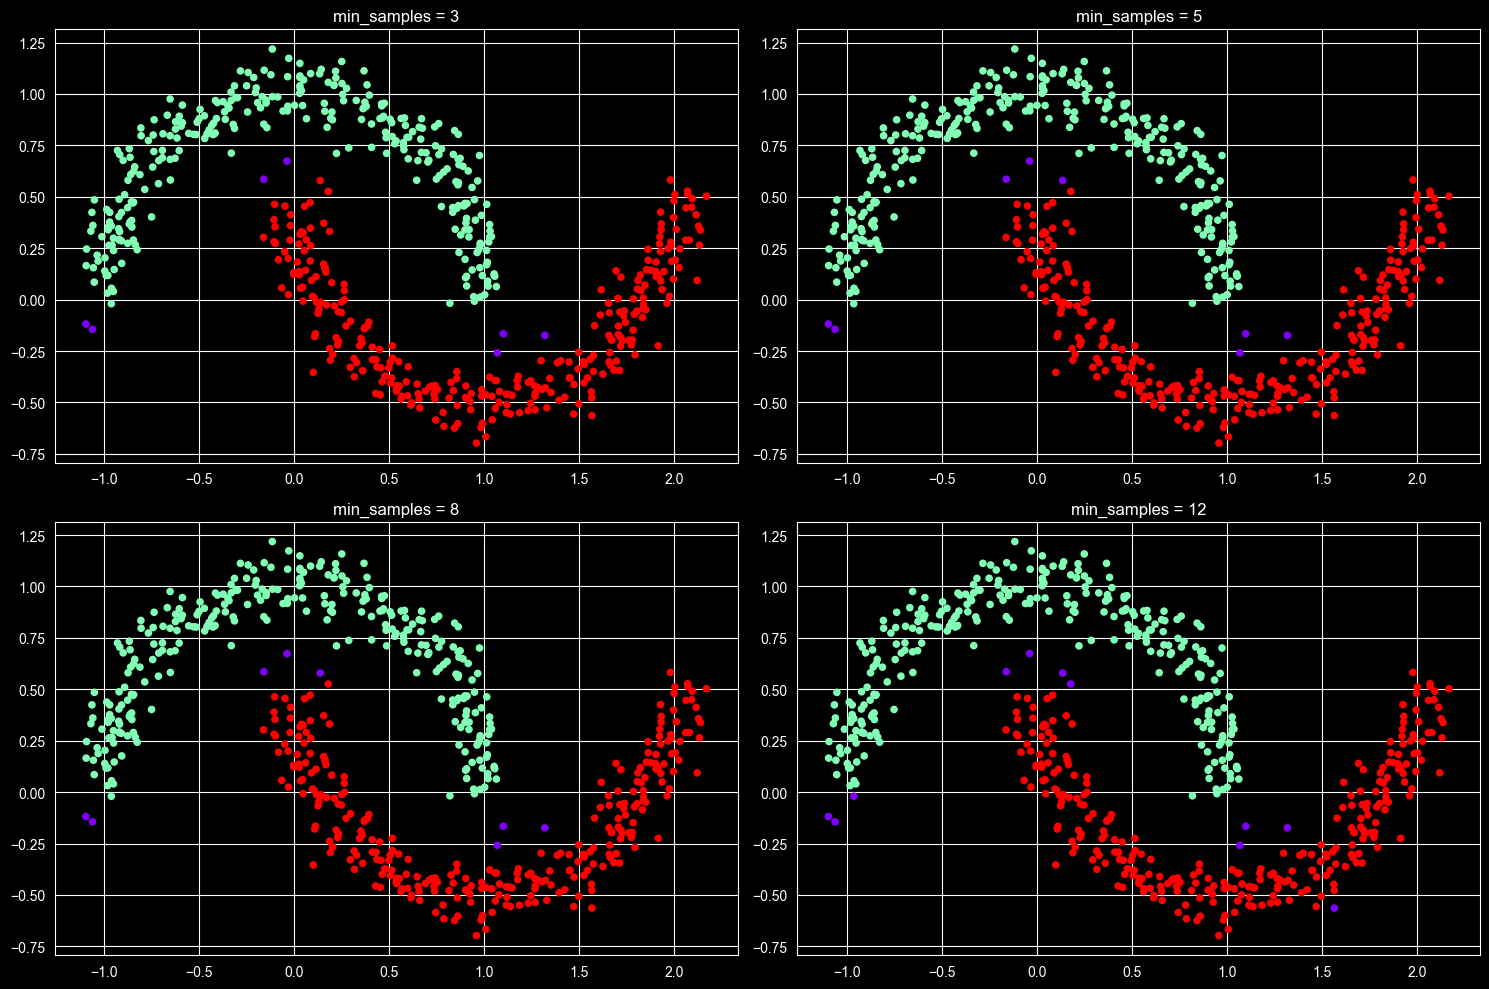

In [23]:
min_samples_list = [3,5,8,12]

plt.figure(figsize=(15,10))

for i, m in enumerate(min_samples_list):

    model = DBSCAN(
        eps=0.22,
        min_samples=m
    )

    labels = model.fit_predict(X_scaled)

    plt.subplot(2,2,i+1)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=labels,
        cmap="rainbow",
        s=20
    )

    plt.title(f"min_samples = {m}")

plt.tight_layout()

plt.show()

In [24]:
# Final Conclusion

print("="*60)
print("DBSCAN Clustering Summary")
print("="*60)

print(f"Total Samples      : {len(X)}")
print(f"Clusters Found     : {n_clusters}")
print(f"Noise Points       : {noise_points}")

if len(set(clusters[mask])) > 1:
    print(f"Silhouette Score   : {score:.3f}")

print("="*60)

DBSCAN Clustering Summary
Total Samples      : 600
Clusters Found     : 2
Noise Points       : 8
Silhouette Score   : 0.392
